# Spike Data: Analisis

Tujuan: mengganti asumsi tentang data kualitas udara Jabodetabek dengan hasil pengukuran,
sebelum menulis kode produk.

## Tujuh pertanyaan yang dijawab

1. Seberapa bisa diandalkan sensor OpenAQ?
2. Seberapa jauh model Open-Meteo meleset dari sensor?
3. Pada jam berapa model paling meleset?
4. Apakah udara benar-benar berbeda dalam jarak dekat?
5. Seberapa sering kategori udara berubah per hari?
6. Seberapa jauh lokasi umum dari sensor yang andal?
7. Seberapa cepat data baru tersedia, dan seberapa sering API gagal?

## Dua sumber data, jangan tertukar

- **[BACKFILL]** 30 hari data per jam dari folder `raw/`. Menjawab "berapa nilainya".
  Dipakai untuk pertanyaan 1 sampai 6.
- **[CRON-JOB]** snapshot per jam dari branch `spike-data`. Menjawab "kapan datanya tersedia".
  Dipakai untuk pertanyaan 7.

In [24]:
import glob, json, re
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import os

WIB = pd.Timedelta(hours=7)

def distance_km(lat1, lon1, lat2, lon2):
    """Jarak garis lurus antara dua titik di permukaan bumi (haversine)."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

## Persiapan A. [CRON-JOB] Cek collector

Apakah collector jalan tiap jam? Berapa jam yang hilang, dan kenapa?

Catatan: sampai 7 Okt pemicunya cron GitHub (banyak dilewati). Setelah itu cron-job.org.
Sel ini dijalankan ulang tiap kali selesai `git pull` di folder `spike-data`.

In [25]:
# [CRON-JOB] sumber: ../../spike-data/spike/raw/collector/*.json
COLLECTOR_DIR = Path("../../spike-data/spike/raw/collector")
NEW_START = pd.Timestamp("2026-10-07 04:00", tz="UTC")   # jam run pertama dari cron-job.org

files = sorted(COLLECTOR_DIR.glob("*.json"))
snaps = [json.loads(f.read_text()) for f in files]        # dipakai lagi di Pertanyaan 7
t = pd.to_datetime([s["fetched_at"] for s in snaps], utc=True).sort_values()
print(len(files), "snapshot")

def hours_loss(t, start, end):
    expected = pd.date_range(start, end, freq="h")
    exist = t[(t >= start) & (t < end + pd.Timedelta(hours=1))].floor("h")
    return len(expected), expected.difference(exist)

n, lost = hours_loss(t, t.min().floor("h"), NEW_START - pd.Timedelta(hours=1))
print(f"Cron GitHub : {n - len(lost)}/{n} jam terisi")

if t.max() >= NEW_START:
    n, lost = hours_loss(t, NEW_START, t.max().floor("h"))
    print(f"cron-job.org: {n - len(lost)}/{n} jam terisi")
    print(lost)

21 snapshot
Cron GitHub : 21/109 jam terisi


## Persiapan B. [BACKFILL] Muat data 30 hari

Menghasilkan tiga tabel yang dipakai pertanyaan 1 sampai 6:
`S` (sensor), `M` (model), `target` (koordinat tiap titik).

In [26]:
# [BACKFILL] sumber: raw/openaq/hours_*.json dan raw/openmeteo/backfill_*.json

# Sensor: satu baris per sensor per jam

rows = []
for path in glob.glob("raw/openaq/hours_*.json"):
    sid = int(re.search(r"hours_(\d+)_p", path).group(1))
    for r in json.load(open(path))["results"]:
        rows.append({
            "sensor_id": sid,
            "hour_utc": r["period"]["datetimeFrom"]["utc"],
            "pm25": r["value"]
        })

sensor = pd.DataFrame(rows)
sensor["hour_utc"] = pd.to_datetime(sensor.hour_utc, utc=True).dt.floor("h")

inv = pd.read_csv("data/sensor/inventory.csv")
sensor = sensor.merge(inv[["pm25_sensor_id", "location_id"]], left_on="sensor_id", right_on="pm25_sensor_id")
sensor["site"] = "s_" + sensor.location_id.astype(str)

# Model: respons multi-lokasi berupa list, urutannya sama dengan targets
bf = json.load(open(sorted(glob.glob("raw/openmeteo/backfill_*.json"))[-1]))
model_rows = []
for tg, resp in zip(bf["targets"], bf["response"]):
    h = resp["hourly"]
    for time_, v in zip(h["time"], h["pm2_5"]):
        model_rows.append({
            "site": tg["id"], 
            "hour_utc": time_, 
            "pm25": v, 
            "cell": (resp["latitude"], resp["longitude"])
        })

model = pd.DataFrame(model_rows)
model["hour_utc"] = pd.to_datetime(model.hour_utc, utc=True)

# Gabungan, disimpan untuk fase berikutnya
obs = pd.concat([sensor.assign(source="sensor")[["site", "source", "hour_utc", "pm25"]],
                 model.assign(source="model")[["site", "source", "hour_utc", "pm25"]]])
obs.to_parquet("data/analytics/obs.parquet")

# Tiga tabel kerja
target = pd.DataFrame(bf["targets"]).set_index("id")
S = (obs[obs.source == "sensor"].dropna(subset=["pm25"])
     .groupby(["site", "hour_utc"], as_index=False).pm25.mean())
M = obs[obs.source == "model"].dropna(subset=["pm25"])

# Cek kesehatan data
print(obs.groupby("source").agg(baris=("pm25", "size"), site=("site", "nunique"),
                                 dari=("hour_utc", "min"), sampai=("hour_utc", "max")))

        baris  site                      dari                    sampai
source                                                                 
model    7104     8 2026-09-01 00:00:00+00:00 2026-10-07 23:00:00+00:00
sensor   1216     2 2026-09-09 06:00:00+00:00 2026-10-07 01:00:00+00:00


In [27]:
print("Lokasi di inventory      :", len(inv))
print("Punya sensor PM2.5       :", inv.pm25_sensor_id.notna().sum())
print("Data < 24 jam            :", (inv.age_hours < 24).sum())
print("Data < 72 jam            :", (inv.age_hours < 72).sum())
print("File hours_*.json        :", len(glob.glob("raw/openaq/hours_*.json")))
print(inv.sort_values("age_hours").head(15).to_string())

Lokasi di inventory      : 28
Punya sensor PM2.5       : 24
Data < 24 jam            : 2
Data < 72 jam            : 2
File hours_*.json        : 2
    location_id                       name       lat         lon            provider  is_monitor  is_mobile  pm25_sensor_id                                                                     params              last_utc     age_hours
27      6539694            Griya Tugu Asri -6.363190  106.841760         AirGradient       False      False      17620437.0                                pm1,pm25,relativehumidity,temperature,um003  2026-10-02T14:00:00Z      1.084186
26      6455006                     BMKG 1 -6.155769  106.842394         AirGradient       False      False      17000275.0                                pm1,pm25,relativehumidity,temperature,um003  2026-10-02T14:00:00Z      1.084186
10      1894639                    Jakarta -6.096570  106.961350             Clarity       False      False       7748548.0                         

In [28]:
new_invent = pd.read_csv("data/sensor/inventory_7okt.csv")
print("Lokasi:", len(new_invent), "| PM2.5:", new_invent.pm25_sensor_id.notna().sum(),
      "| aktif < 24 jam:", (new_invent.age_hours < 24).sum())
print(new_invent[new_invent.age_hours < 24][["name", "provider", "last_utc"]])

Lokasi: 28 | PM2.5: 24 | aktif < 24 jam: 2
               name     provider              last_utc
26           BMKG 1  AirGradient  2026-10-07T05:00:00Z
27  Griya Tugu Asri  AirGradient  2026-10-07T08:00:00Z


## Pertanyaan 1. Seberapa bisa diandalkan sensor OpenAQ?

Sumber: [BACKFILL]
Yang diukur: uptime dan bolong terpanjang per sensor.
Keputusan yang diisi: ambang staleness, wilayah MVP.

**Hasil:**

           occupied_hour  uptime_percentage  empty_hour
site                                                   
s_6455006            668              100.0         0.0
s_6539694            548               82.0         0.0
Uptime > 90%: 1 dari 2
Uptime < 50%: 0
Empty hours median: 0.0 jam


<Axes: title={'center': 'Uptime sensor PM2.5'}, ylabel='site'>

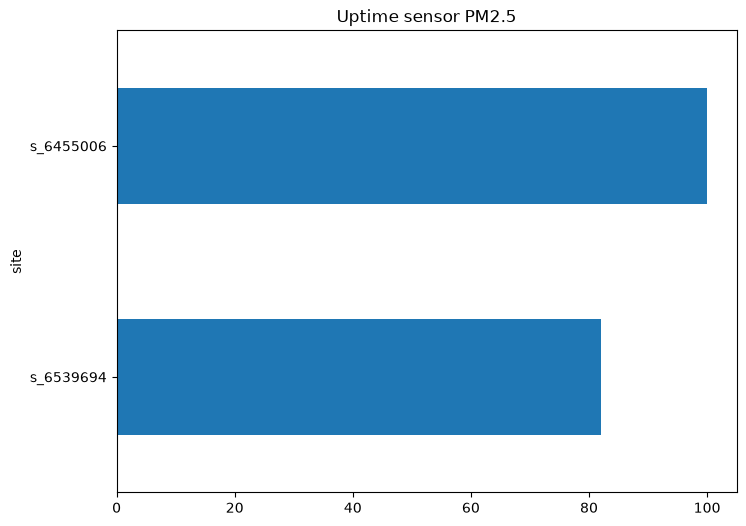

In [29]:
# [BACKFILL] Pertanyaan 1: uptime dan bolong terpanjang per sensor
total_hour = (S.hour_utc.max() - S.hour_utc.min()) / pd.Timedelta(hours=1) + 1
q1 = S.groupby("site").hour_utc.nunique().to_frame("occupied_hour")
q1["uptime_percentage"] = (q1.occupied_hour / total_hour * 100).round(1)
q1["empty_hour"] = S.groupby("site").hour_utc.apply(
    lambda h: (h.sort_values().diff().dt.total_seconds() / 3600).max() - 1
)

print(q1.sort_values("uptime_percentage", ascending=False))
print("Uptime > 90%:", (q1.uptime_percentage > 90).sum(), "dari", len(q1))
print("Uptime < 50%:", (q1.uptime_percentage < 50).sum())
print("Empty hours median:", q1.empty_hour.median(), "jam")
q1.uptime_percentage.sort_values().plot.barh(figsize=(8,6), title= "Uptime sensor PM2.5")

In [30]:
print(S.groupby("site").hour_utc.agg(["min", "max", "nunique"]))

                                min                       max  nunique
site                                                                  
s_6455006 2026-09-09 06:00:00+00:00 2026-10-07 01:00:00+00:00      668
s_6539694 2026-09-14 06:00:00+00:00 2026-10-07 01:00:00+00:00      548


In [31]:
for site, g in S.sort_values("hour_utc").groupby("site"):
    sama = (g.pm25 != g.pm25.shift()).cumsum()
    print(site, "| deret nilai sama terpanjang:", g.groupby(sama).size().max(), "jam",
          "| min:", g.pm25.min(), "| max:", g.pm25.max())

s_6455006 | deret nilai sama terpanjang: 2 jam | min: 22.2 | max: 236.0
s_6539694 | deret nilai sama terpanjang: 2 jam | min: 28.4 | max: 170.0


Kesimpulan:
Dari 24 sensor PM2.5 terdaftar, 2 yang masih mengirim data. Keduanya stabil: satu terisi 100% selama 28 hari, satu lagi tanpa putus sejak mulai mengirim. Masalahnya jumlah, bukan keandalan.

Tidak ada nilai macet (deret sama terpanjang 2 jam). Rentang 22 sampai 236 µg/m³. Nilai terendah tidak pernah masuk kategori baik. Puncak perlu dibaca hati-hati karena sensor murah bisa membaca berlebih saat lembap.

## Pertanyaan 2. Seberapa jauh model Open-Meteo meleset dari sensor?

Sumber: [BACKFILL]
Yang diukur: bias dan rata-rata selisih (MAE), di lokasi dan jam yang sama.
Keputusan yang diisi: baseline error yang harus dikalahkan fusi.
Cara baca: bias negatif berarti model menebak terlalu rendah.

**Hasil:**

In [32]:
# [BACKFILL] Pertanyaan 2: bias dan MAE model terhadap sensor
pair = S.merge(M, on=["site", "hour_utc"], suffixes=("_sensor", "_model"))
pair["err"] = pair.pm25_model - pair.pm25_sensor

print("Jumlah pasangan:", len(pair))
print("Bias (model - sensor):", round(pair.err.mean(), 1), "µg/m³")
print("MAE:", round(pair.err.abs().mean(), 1), "µg/m³")

q2 = pair.groupby("site").err.agg(bias="mean", mae=lambda e: e.abs().mean()).round(1)
print(q2.sort_values("mae"))

Jumlah pasangan: 1216
Bias (model - sensor): -2.2 µg/m³
MAE: 24.5 µg/m³
           bias   mae
site                 
s_6455006 -15.2  18.6
s_6539694  13.7  31.8


In [33]:
print(model[model.site.isin(["s_6455006", "s_6539694"])].groupby("site").cell.first())
print(pair.groupby("site")[["pm25_sensor", "pm25_model"]].mean().round(1))
print(pair.groupby("site").apply(lambda g: g.pm25_sensor.corr(g.pm25_model)).round(2))

site
s_6455006     (-6.199997, 106.80002)
s_6539694    (-6.4000015, 106.80002)
Name: cell, dtype: object
           pm25_sensor  pm25_model
site                              
s_6455006         61.5        46.3
s_6539694         81.1        94.7
site
s_6455006    0.54
s_6539694    0.39
dtype: float64


Model berguna sebagai gambaran latar (wilayah mana yang cenderung lebih kotor), tapi tidak cukup untuk nilai per jam di satu lokasi. Selisih rata-rata 24,5 µg/m³, setara satu kategori. Koreksi harus per lokasi karena arah melesetnya berbeda.

## Pertanyaan 3. Pada jam berapa model paling meleset?

Sumber: [BACKFILL]
Yang diukur: error model per jam dalam sehari (WIB).
Keputusan yang diisi: kapan sensor paling dibutuhkan.

**Hasil:**

          bias   mae
time_wib            
0         13.5  29.8
1         12.0  29.4
2         11.1  25.9
3         12.5  29.0
4         14.4  28.2
5         11.2  34.9
6         20.3  33.6
7          7.2  28.6
8        -10.1  24.1
9        -22.2  23.4
10       -28.0  28.0
11       -29.2  29.2
12       -25.6  25.7
13       -17.3  18.9
14       -12.4  13.2
15       -10.1  11.9
16        -8.4  11.5
17        -7.5  13.3
18        -3.5  16.9
19        -4.0  22.2
20        -2.9  25.1
21         1.0  27.7
22         9.3  28.3
23        12.1  30.7


<Axes: title={'center': 'Error model per jam (WIB)'}, xlabel='time_wib'>

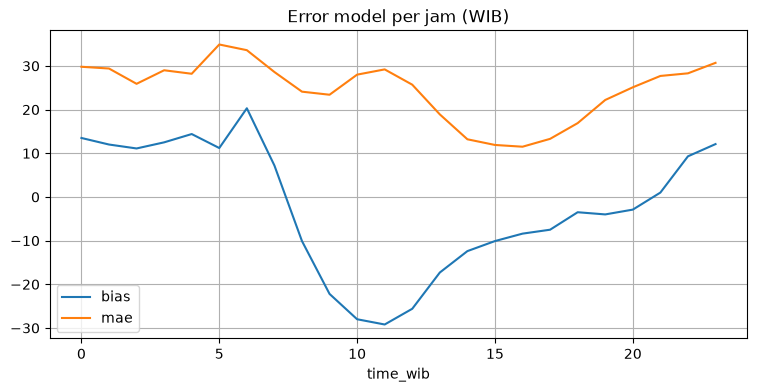

In [34]:
# [BACKFILL] Pertanyaan 3: error model per jam (memakai `pair` dari Pertanyaan 2)
pair["time_wib"] = (pair.hour_utc + WIB).dt.hour
q3 = pair.groupby("time_wib").err.agg(bias="mean", mae=lambda e: e.abs().mean()).round(1)
print(q3)
q3.plot(figsize=(9, 4), title="Error model per jam (WIB)", grid=True)

In [35]:
print(pair.groupby(["time_wib", "site"]).err.mean().unstack().round(1))

site      s_6455006  s_6539694
time_wib                      
0             -10.6       42.8
1             -12.1       41.5
2             -11.0       38.1
3             -11.3       41.6
4              -8.7       42.6
5             -15.8       44.1
6              -3.0       48.7
7             -11.1       29.6
8             -21.7        4.2
9             -26.9      -16.4
10            -29.6      -26.1
11            -26.7      -32.2
12            -19.0      -33.6
13            -11.9      -23.8
14             -8.9      -16.7
15            -11.2       -8.8
16            -13.0       -2.7
17            -14.5        1.1
18            -14.4        9.8
19            -18.6       13.7
20            -20.7       18.8
21            -19.4       25.9
22            -14.0       37.8
23            -11.3       40.7


Per lokasi polanya berbeda. Kemayoran: model selalu terlalu rendah (−3 sampai −30). Depok: model terlalu tinggi 38 sampai 49 pada malam hari, lalu terlalu rendah 16 sampai 34 pada pukul 09.00 sampai 14.00. Yang sama di keduanya: pukul 09.00 sampai 13.00 model terlalu rendah 20 sampai 33. Koreksi harus per lokasi dan per jam. Penyebab ayunan di Depok belum diketahui.

## Pertanyaan 4. Apakah udara benar-benar berbeda dalam jarak dekat?

Sumber: [BACKFILL]
Yang diukur: beda PM2.5 antarsensor dibanding jaraknya, dan jumlah kotak model.
Keputusan yang diisi: resolusi H3, radius sensor.

**Tebakan saya sebelum menjalankan:**

           a          b  distance_km  median_diff  corelation
0  s_6455006  s_6539694        23.06         19.8        0.52
Jumlah kotak model yang berbeda: 7 untuk 8 titik


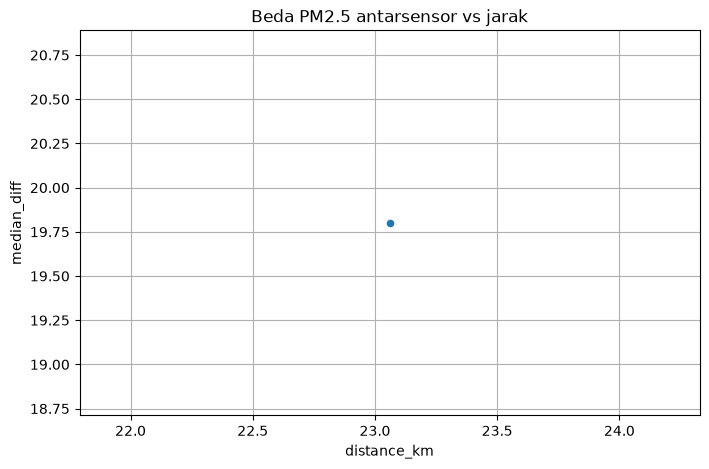

In [36]:
# [BACKFILL] Pertanyaan 4: beda antarsensor pada jam yang sama vs jarak
wide = S.pivot(index="hour_utc", columns="site", values="pm25")   # dipakai lagi di Pertanyaan 5
rows = []
for a, b in combinations(wide.columns, 2):
    both = wide[[a, b]].dropna()
    if len(both) < 100:            # terlalu sedikit jam bersama, lewati
        continue
    rows.append({"a": a, "b": b,
                 "distance_km": distance_km(target.lat[a], target.lon[a], target.lat[b], target.lon[b]),
                 "median_diff": (both[a] - both[b]).abs().median(),
                 "corelation": both[a].corr(both[b])})
q4 = pd.DataFrame(rows).round(2).sort_values("distance_km")
print(q4)
q4.plot.scatter(x="distance_km", y="median_diff", figsize=(8, 5), grid=True,
                title="Beda PM2.5 antarsensor vs jarak")

# Pembanding: berapa kotak model yang berbeda untuk seluruh titik?
print("Jumlah kotak model yang berbeda:", model.cell.nunique(), "untuk", model.site.nunique(), "titik")

In [37]:
for c in sorted(model.cell.unique()):
    print(c)

(-6.4000015, 106.80002)
(-6.4000015, 106.899994)
(-6.2999954, 106.70001)
(-6.199997, 106.600006)
(-6.199997, 106.70001)
(-6.199997, 106.80002)
(-6.199997, 107)


Hanya satu pasangan sensor (23 km). Beda median 19,8 µg/m³ dan korelasi 0,52: udara di dua titik berbeda nyata dan hanya separuh bergerak bersama. Perilaku pada jarak di bawah 23 km tidak bisa diketahui dari data ini. Model memakai 7 kotak untuk 8 titik, lebih rapat dari perkiraan awal.


## Pertanyaan 5. Seberapa sering kategori udara berubah per hari?

Sumber: [BACKFILL]
Yang diukur: jumlah pergantian kategori, nilai per jam dibanding rata-rata 24 jam.
Keputusan yang diisi: dasar notifikasi dan hysteresis.

**Hasil:*

In [38]:
# [BACKFILL] Pertanyaan 5: pergantian kategori per hari (memakai `wide` dari Pertanyaan 4)
batas = [0, 9.0, 35.4, 55.4, 125.4, 225.4, np.inf]          # ambang PM2.5 US AQI
label = ["Baik", "Sedang", "Sensitif", "Tidak sehat", "Sangat tidak sehat", "Berbahaya"]

def ganti_per_hari(seri):
    kategori = pd.cut(seri.dropna(), batas, labels=label, include_lowest=True)
    hari = (seri.index.max() - seri.index.min()) / pd.Timedelta(days=1)
    return (kategori != kategori.shift()).sum() / max(hari, 1)

q5 = pd.DataFrame({
    "per_hour": wide.apply(ganti_per_hari),
    "average_24hours": wide.rolling("24h", min_periods=12).mean().apply(ganti_per_hari),
}).round(1)
print(q5)
print(q5.median())

           per_hour  average_24hours
site                                
s_6455006       4.4              0.5
s_6539694       2.8              0.1
per_hour           3.6
average_24hours    0.3
dtype: float64


In [39]:
def ganti_tahan(seri, tahan=2):
    """Hitung pergantian kategori yang bertahan minimal `tahan` jam."""
    kategori = pd.cut(seri.dropna(), batas, labels=False, include_lowest=True)
    blok = (kategori != kategori.shift()).cumsum()
    lama = kategori.groupby(blok).transform("size")
    stabil = kategori[lama >= tahan]
    hari = (seri.index.max() - seri.index.min()) / pd.Timedelta(days=1)
    return (stabil != stabil.shift()).sum() / max(hari, 1)

print(pd.DataFrame({
    "per_jam": wide.apply(ganti_per_hari),
    "rata2_3jam": wide.rolling("3h", min_periods=2).mean().apply(ganti_per_hari),
    "per_jam_tahan_2jam": wide.apply(ganti_tahan),
    "rata2_24jam": wide.rolling("24h", min_periods=12).mean().apply(ganti_per_hari),
}).round(1))

           per_jam  rata2_3jam  per_jam_tahan_2jam  rata2_24jam
site                                                           
s_6455006      4.4         3.1                 3.1          0.5
s_6539694      2.8         1.5                 1.6          0.1


Per jam kategori berganti 2,8 sampai 4,4 kali sehari. Dengan rata-rata 24 jam hanya 0,1 sampai 0,5 kali, karena level harian hampir selalu berada di kategori yang sama. Notifikasi berbasis rata-rata 24 jam akan nyaris tidak pernah berbunyi. Perlu dasar di tengah: rata-rata 3 jam atau hysteresis.

Rata-rata 3 jam dan aturan tahan 2 jam sama-sama menurunkan jadi 1,5 sampai 3,1 kali sehari. Sebagian besar pergantian adalah perubahan nyata, bukan goyangan. Lokasi yang levelnya dekat ambang berganti dua kali lebih sering.


## Pertanyaan 6. Seberapa jauh lokasi umum dari sensor yang andal?

Sumber: [BACKFILL]
Yang diukur: jarak tiap titik uji ke sensor andal terdekat (uptime di atas 80%).
Keputusan yang diisi: radius sensor, wilayah MVP.

**Hasil:**

In [40]:
# [BACKFILL] Pertanyaan 6: jarak titik uji ke sensor andal (memakai `q1` dari Pertanyaan 1)
andal = q1.index[q1.uptime_percentage >= 80]
titik = target[target.group != "sensor"]

q6 = titik.apply(lambda p: min(distance_km(p.lat, p.lon, target.lat[s], target.lon[s]) for s in andal),
                 axis=1).round(1).to_frame("km_ke_sensor_andal")
q6["group"] = titik.group
print(q6.sort_values("km_ke_sensor_andal"))
for r in (2, 5, 10):
    print(f"Dalam {r} km:", (q6.km_ke_sensor_andal <= r).sum(), "dari", len(q6), "titik")

              km_ke_sensor_andal group
id                                    
cibubur                      5.3  edge
depok                        6.8  edge
bekasi                      17.4  edge
rumah/kantor                21.0  edge
bsd                         21.9  edge
tangerang                   23.4  edge
Dalam 2 km: 0 dari 6 titik
Dalam 5 km: 0 dari 6 titik
Dalam 10 km: 2 dari 6 titik


Tidak ada titik uji dalam 5 km dari sensor. Dua dari enam dalam 10 km, empat lainnya 17 sampai 23 km. Pada jarak itu sensor hampir tidak mewakili kondisi setempat (lihat Pertanyaan 4), jadi nilai di sana praktis hanya dari model.

## SUMMARY

Pertanyaan	Temuan
1. Sensor andal?	**Yang ada stabil, tapi hanya 2 dari 24 yang masih mengirim data**
2. Model meleset berapa?	**Sekitar 24,5 µg/m³, setara satu kategori. Arahnya berlawanan di dua lokasi**
3. Jam berapa paling meleset?	**Pukul 09.00 sampai 13.00 model terlalu rendah di kedua lokasi. Malam hari berbeda per lokasi**
4. Beda dalam jarak dekat?	**Pada 23 km berbeda nyata. Jarak yang lebih dekat tidak bisa diukur**
5. Kategori sering berubah?	**3 sampai 4 kali sehari per jam, hampir tidak pernah dengan rata-rata 24 jam**
6. Jarak ke sensor?	**Nilai tengah sekitar 19 km dari enam titik uji**

## ANOTHER SOURCE

In [51]:
oaq = pd.read_csv("data/sensor/inventory_7okt.csv")
oaq = oaq[oaq.pm25_sensor_id.notna()].assign(source="openaq", sensor_id=lambda d: d.location_id)
oaq = oaq[["source", "sensor_id", "name", "lat", "lon", "age_hours"]] 

ignored_files = ['inventory.csv', 'inventory_7okt.csv']
others = pd.concat([pd.read_csv(p) for p in glob.glob("data/sensor/*.csv") if os.path.basename(p) not in ignored_files], ignore_index=True)
all_data = pd.concat([oaq, others], ignore_index=True)

for col in ["lat", "lon", "age_hours"]:
    all_data[col] = pd.to_numeric(all_data[col], errors="coerce")
all_data = all_data.dropna(subset=["lat", "lon"])

summary = all_data.groupby("source").agg(registered=("sensor_id", "size"), active_in_24h=("age_hours", lambda a: (a < 24).sum()))
print(summary)


             registered  active_in_24h
source                                
airgradient          10             10
openaq               24              2
purpleair            15              4
waqi                 15             15


In [52]:
# [ANOTHER SOURCE] sensor aktif unik dari semua sumber, lalu ulangi hitungan Pertanyaan 6
active = all_data[all_data.age_hours < 24].copy()
active["near"] = active.lat.round(3).astype(str) + "," + active.lon.round(3).astype(str)
unique = active.drop_duplicates("near")
print("Active sensors:", len(active), "| unique location:", len(unique))

point = target[target.group != "sensor"]
new_distance = point.apply(
    lambda p: distance_km(p.lat, p.lon, unique.lat.values, unique.lon.values).min(), axis=1).round(1)

compared = pd.DataFrame({"hanya_openaq": q6.km_ke_sensor_andal, "semua_sumber": new_distance})
print(compared)

for r in (2, 5, 10):
    print(f"Dalam {r} km:", (new_distance <= r).sum(), "dari", len(point), "titik")

Active sensors: 31 | unique location: 30
              hanya_openaq  semua_sumber
id                                      
bekasi                17.4           1.9
depok                  6.8           6.8
cibubur                5.3           5.3
tangerang             23.4           1.0
bsd                   21.9           5.7
rumah/kantor          21.0           0.9
Dalam 2 km: 3 dari 6 titik
Dalam 5 km: 3 dari 6 titik
Dalam 10 km: 6 dari 6 titik


In [49]:
u = unique.reset_index(drop=True)
d = distance_km(u.lat.values[:, None], u.lon.values[:, None], u.lat.values[None, :], u.lon.values[None, :])
i, j = np.where((d < 0.3) & (np.triu(np.ones_like(d), 1) > 0))
print(pd.DataFrame({"a": u.source[i].values, "b": u.source[j].values,
                    "nama_a": u.name[i].values, "nama_b": u.name[j].values,
                    "jarak_m": (d[i, j] * 1000).round()}))

        a          b  nama_a             nama_b  jarak_m
0  openaq  purpleair  BMKG 1  Angkasa-Kemayoran     28.0


In [53]:
print(active[active.duplicated("near", keep=False)].sort_values("near")[["source", "name", "near"]])

         source             name            near
23       openaq  Griya Tugu Asri  -6.363,106.842
48  airgradient  Griya Tugu Asri  -6.363,106.842
